# Attack day model training

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
from pathlib import Path


PROJECT_ROOT = Path("/content/drive/MyDrive/master-thesis").resolve()

SRC_PATH = PROJECT_ROOT / "src"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

os.chdir(PROJECT_ROOT)

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from notebooks.targeted_experiment_utils import (
    ATSSetup,
    TARGET_SIGNALS,
    candidate_attack_days,
    compute_summary_by_setup_and_timing,
    compute_timing_summaries,
    compute_summary_by_setup,
    run_targeted_attack_experiment,
)

from scr.attack_day_model.create_data import create_attack_event_log
from scr.attack_day_model.preprocessing import prepare_attack_day_dataset, feature_correlation_analysis, TECHNICAL_FEATURE_COLUMNS

MODEL_FOLDERS = {
    "LSTM": NOTEBOOK_DIR / "models/LSTM_13_years",
    "LSTM3y": NOTEBOOK_DIR / "models/LSTM_3_years",
    "LSTM_cumulative": NOTEBOOK_DIR / "models/LSTM_cumulative",
    "LSTM_rolling": NOTEBOOK_DIR / "models/LSTM_rolling",
    "transformer": NOTEBOOK_DIR / "models/transformer",
}

DATA_FOLDER = PROJECT_ROOT / "data/validation_time"

DATA_START = "2013-01-01"
VALIDATION_START = "2021-01-01"
VALIDATION_END = "2023-10-23"
ATTACK_START = "2014-01-01"
ATTACK_END = "2026-06-01"
QUARTERLY_MONTHS = 3
EVALUATION_WINDOW_DAYS = 20

TRAIN_MODE_BY_SETUP = {
    "LSTM_rolling_ALL_MA": "rolling",
    "LSTM_rolling_All_BB": "rolling",
    "LSTM_rolling_All_ROC": "rolling",
    "LSTM_cumulative_All_BB": "cumulative",
    "LSTM3y_All_BB": "cumulative", # for single models this parameter is irrelevant
    "LSTM13y_All_BB": "cumulative", # same
}

EXPERIMENT_NAME = "attack_dataset"
DATASET_DIR = PROJECT_ROOT / "data/attack_dataset"
DATASET_PATH = DATASET_DIR / f"{EXPERIMENT_NAME}.csv"

ALL_TICKERS = [
    "GOOGL", "AMZN", "AAPL", "PEP", "JNJ", "PFE", "MRK", "ABBV", "PG", "KO",
    "WMT", "JPM", "BAC", "GS", "V", "XOM", "CVX", "COP", "BP", "BA",
    "MMM", "HON", "GE", "T", "VZ", "TMUS", "HSY", "DUK", "SO", "EXC", "AEP",
    "AMT", "PLD", "SPG", "BHP", "RIO", "VALE", "FCX",
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_PATH:", SRC_PATH)
print("Current dir:", Path.cwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/master-thesis
SRC_PATH: /content/drive/MyDrive/master-thesis/src
Current dir: /content/drive/MyDrive/master-thesis


In [2]:
SETUPS = [
    #ATSSetup("LSTM_rolling_All_MA", tuple(ALL_TICKERS), "MA", model_name="LSTM_rolling", model_variant="quarterly", attacked_ticker="GOOGL"),
    #ATSSetup("LSTM_cumulative_All_MA", tuple(ALL_TICKERS), "MA", model_name="LSTM_cumulative", model_variant="quarterly", attacked_ticker="GOOGL"),
    #ATSSetup("LSTM3y_All_MA", tuple(ALL_TICKERS), "MA", model_name="LSTM3y", model_variant="single", attacked_ticker="GOOGL"),
    #ATSSetup("LSTM13y_All_MA", tuple(ALL_TICKERS), "MA", model_name="LSTM", model_variant="single", attacked_ticker="GOOGL"),
    ATSSetup("LSTM3y_All_ROC", tuple(ALL_TICKERS), "ROC", model_name="LSTM3y", model_variant="single", attacked_ticker="GOOGL"),
    ATSSetup("LSTM13y_All_ROC", tuple(ALL_TICKERS), "ROC", model_name="LSTM", model_variant="single", attacked_ticker="GOOGL"),


    # ATSSetup("transformer_All_MA", tuple(ALL_TICKERS), "MA", model_name="transformer", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM3y_All_ROC", tuple(ALL_TICKERS), "ROC", model_name="LSTM3y", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM3y_All_BB", tuple(ALL_TICKERS), "BB", model_name="LSTM3y", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_All_MA", tuple(ALL_TICKERS), "MA", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_All_ROC", tuple(ALL_TICKERS), "ROC", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_All_BB", tuple(ALL_TICKERS), "BB", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_GOOGL_MA", ("GOOGL",), "MA", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_Tech3_MA", ("GOOGL","AAPL","AMZN"), "MA", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_Tech3_BB", ("GOOGL","AAPL","AMZN"), "BB", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_Tech3_ROC", ("GOOGL","AAPL","AMZN"), "ROC", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_Defensive_MA", ("JNJ","PG","KO"), "MA", attacked_ticker="JNJ"),
]

SEQUENCE_LENGTH = 50
MAX_ABS_DELTA   = 0.35
GRID_STEPS      = 35

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Create dataset

In [ ]:
print("Preparing attack days range for each setup...")
DATASET_DIR.mkdir(parents=True, exist_ok=True)
print(f"Creating attack event log at: {DATASET_PATH}")

for setup in SETUPS:
    train_mode = TRAIN_MODE_BY_SETUP.get(setup.name, "cumulative")
    attack_days = candidate_attack_days(
        setup=setup,
        model_folders=MODEL_FOLDERS,
        project_root=PROJECT_ROOT,
        data_folder=DATA_FOLDER,
        sequence_length=SEQUENCE_LENGTH,
        min_day=0,
        simulation_start=ATTACK_START,
        simulation_end=VALIDATION_START,
        data_start=DATA_START,
        months=QUARTERLY_MONTHS,
        train_mode=train_mode,
    )
    print(f"  {setup.name}: {attack_days.tolist()}")
    create_attack_event_log(
        setups=[setup],
        attack_days=attack_days,
        model_folders=MODEL_FOLDERS,
        project_root=PROJECT_ROOT,
        output_csv=DATASET_PATH,
        target_signals=TARGET_SIGNALS,
        timing_policy="manual",
        data_folder=DATA_FOLDER,
        sequence_length=SEQUENCE_LENGTH,
        max_abs_delta=MAX_ABS_DELTA,
        steps=GRID_STEPS,
        simulation_start=ATTACK_START,
        simulation_end=VALIDATION_START,
        data_start=DATA_START,
        months=QUARTERLY_MONTHS,
        eval_cr_period=EVALUATION_WINDOW_DAYS,
        train_mode=train_mode,
        resume=True,
        ignore_already_target=True,
        checkpoint_every=10,
        verbose=True,
    )

event_log = pd.read_csv(DATASET_PATH)
print(f"\nEvent log saved in: {DATASET_PATH}")
print(event_log.head().to_string(index=False))
print(f"Rows saved: {len(event_log)}")

Preparing attack days range for each setup...
Creating attack event log at: /content/drive/MyDrive/master-thesis/data/attack_dataset/attack_dataset.csv
  LSTM3y_All_MA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 

In [3]:
def count_attack_outcomes(df):
    """
    Conta:
    - positive: delta_cumulative_return_in_period < 0
    - negative: delta_cumulative_return_in_period è NaN
    - hard_negative: delta_cumulative_return_in_period > 0
    """
    
    col = df["delta_cumulative_return_in_period"]

    positive = (col < 0).sum()
    negative = col.isna().sum()
    hard_negative = (col > 0).sum()

    return {
        "positive": int(positive),
        "negative": int(negative),
        "hard_negative": int(hard_negative),
    }

In [7]:
DATASET_DIR = PROJECT_ROOT / "data/attack_dataset"
DATASET_PATH = DATASET_DIR / f"{EXPERIMENT_NAME}.csv"

# Load results
if DATASET_PATH.exists():
    print(f"Loading results from: {DATASET_PATH}")
    df = pd.read_csv(DATASET_PATH)
else:
    print(f"Error: {DATASET_PATH} not found.")

results = count_attack_outcomes(df)

print(f"Positive: {results['positive']}")
print(f"Negative: {results['negative']}")
print(f"Hard negative: {results['hard_negative']}")

Loading results from: /content/drive/MyDrive/master-thesis/data/attack_dataset/attack_dataset.csv
Positive: 749
Negative: 4580
Hard negative: 679


## Preprocess data

In [ ]:
print("Preprocessing attack dataset for ML training...")

attack_dataset = prepare_attack_day_dataset(
    csv_path=DATASET_PATH,
    price_data_folder=DATA_FOLDER,
    simulation_start=ATTACK_START,
    simulation_end=ATTACK_END,
    data_start=DATA_START,
    sequence_length=SEQUENCE_LENGTH,
    ohlcv_window=20,
    target_col="target",
    include_categoricals=True,
    drop_invalid=True,
    drop_already_target=True,
    prefer_download=True,
    verbose=True,
)

raw_attack_log = attack_dataset["raw"]
feature_df = attack_dataset["features"]

X_all = attack_dataset["X"]
y = attack_dataset["y"]

ohlcv_cols = [c for c in X_all.columns if c.startswith("ohlcv_lag_")]
X = X_all[TECHNICAL_FEATURE_COLUMNS + ohlcv_cols].copy()

print(f"Raw rows: {len(raw_attack_log)}")
print(f"Feature rows: {len(feature_df)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

FEATURE_DATASET_PATH = DATASET_DIR / f"{EXPERIMENT_NAME}_features.csv"
feature_df.to_csv(FEATURE_DATASET_PATH, index=False)
print(f"Preprocessed dataset saved in: {FEATURE_DATASET_PATH}")

Preprocessing attack dataset for ML training...
Built 6097 feature rows. Skipped 0.
Raw rows: 6097
Feature rows: 6097
X shape: (6097, 114)
y shape: (6097,)
Preprocessed dataset saved in: /content/drive/MyDrive/master-thesis/data/attack_dataset/attack_dataset_features.csv


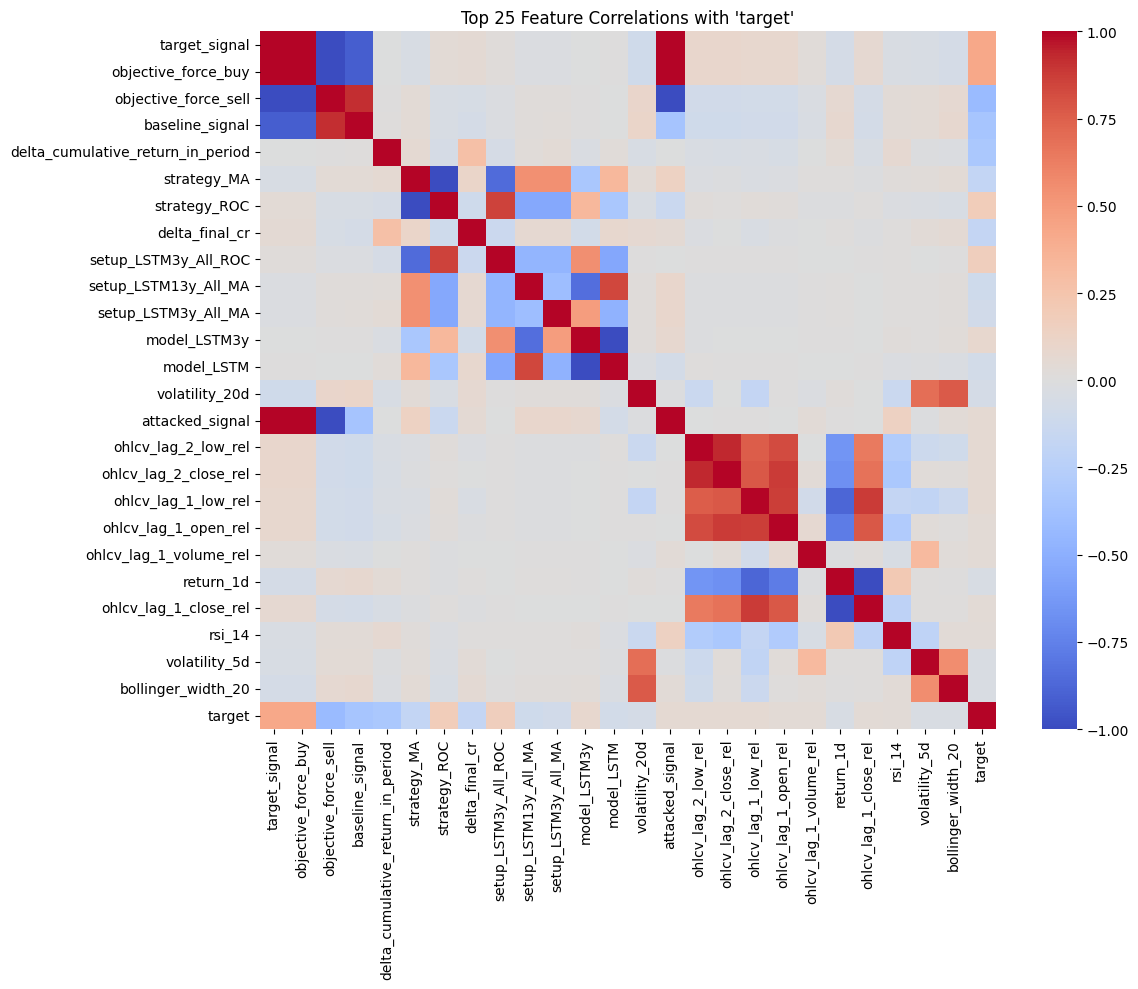


Top features correlated with target:

target_signal                        0.422387
objective_force_buy                  0.422387
objective_force_sell                -0.422387
baseline_signal                     -0.350726
delta_cumulative_return_in_period   -0.324392
strategy_MA                         -0.180330
strategy_ROC                         0.180330
delta_final_cr                      -0.178042
setup_LSTM3y_All_ROC                 0.168148
setup_LSTM13y_All_MA                -0.106398
setup_LSTM3y_All_MA                 -0.090344
model_LSTM3y                         0.081472
model_LSTM                          -0.081472
volatility_20d                      -0.068052
attacked_signal                      0.061836
ohlcv_lag_2_low_rel                  0.056265
ohlcv_lag_2_close_rel                0.055067
ohlcv_lag_1_low_rel                  0.055008
ohlcv_lag_1_open_rel                 0.046762
ohlcv_lag_1_volume_rel               0.042694
return_1d                           -0.04

,target
target_signal,0.422387
objective_force_buy,0.422387
objective_force_sell,-0.422387
baseline_signal,-0.350726
delta_cumulative_return_in_period,-0.324392
...,...
ohlcv_lag_8_high_rel,-0.000226
ohlcv_lag_12_close_rel,0.000019
ohlcv_lag_0_close_rel,NaN
attacked_ticker_GOOGL,NaN


In [6]:
feature_correlation_analysis(
    attack_dataset["features"],
    target_col="target",
    top_k=25
)

## Train model

In [ ]:
y

## Evaluate model